In [1]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import files

print("Upload your dataset ZIP here.")
uploaded = files.upload()


Upload your dataset ZIP here.


Saving btp_2_alt.v3i.yolov11.zip to btp_2_alt.v3i.yolov11.zip


In [5]:
!unzip btp_2_alt.v3i.yolov11.zip -d /content/


Archive:  btp_2_alt.v3i.yolov11.zip
 extracting: /content/valid/images/03bab48b-962b-4c08-bc98-da95237d20ac___RS_LB-3190_JPG.rf.2d063f41646e1c167c59292947700ba8.jpg  
 extracting: /content/train/images/2b6f9564-80a2-4db7-a5e6-72be5ef33a71___RS_Early-B-8009_JPG.rf.772f94e78974c5e5a99667d7c4b29fc8.jpg  
 extracting: /content/test/images/14efc692-8ac6-4bd8-a71a-943192d6831a___RS_Early-B-6841_JPG.rf.bc6f3ace8dbedac6e7e9eccd00ba5c56.jpg  
 extracting: /content/train/images/24482fe2-5139-4f73-909e-9ea4a3d8bf5d___RS_LB-4733_JPG.rf.c374715aa6fdadd9c3fe2be3ac2ab99a.jpg  
 extracting: /content/test/images/2addf5f2-acc5-448c-88a1-fe357d9aa9ac___RS_LB-4736_JPG.rf.b9edde693dbda0e5490a1788eb609bd9.jpg  
 extracting: /content/train/images/0d9dbf50-53a9-42b2-8b29-0360fb7dbd98___RS_Early-B-6692_JPG.rf.1f28f9746425e5f9ef4f48e265e37ccb.jpg  
 extracting: /content/valid/images/3613b972-6af8-4a9a-be7f-bf68e4eb4cd0___RS_Early-B-6813_JPG.rf.a227b77f850a27e4b3cd1083ffbadd8b.jpg  
 extracting: /content/valid/i

In [6]:
yaml_content = """
train: /content/train/images
val: /content/valid/images

names:
  0: early_blight
  1: late_blight
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")


data.yaml created successfully!


In [7]:

model = YOLO("/content/yolo11s.pt")



In [34]:
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train-3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

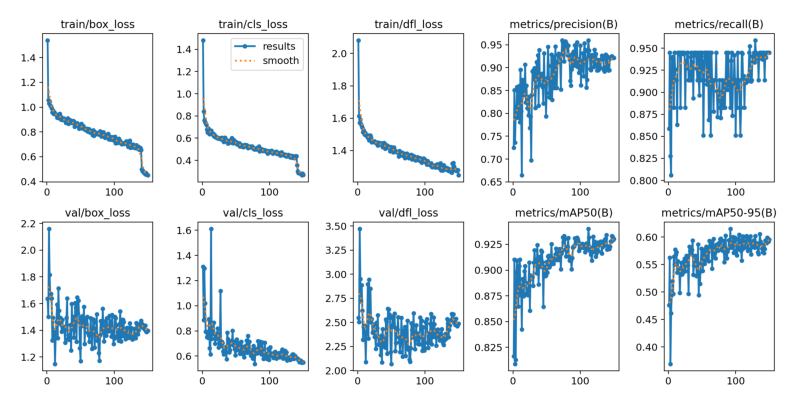

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/runs/detect/train-3/results.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')
plt.show()


In [12]:
os.makedirs("test_images", exist_ok=True)
print("Upload test images now.")


Upload test images now.


In [27]:
model = YOLO("/content/runs/detect/train-3/weights/best.pt")

model.predict(
    source="/content/test/images",
    save=True,
    imgsz=640,
    conf=0.25
)



image 1/40 /content/test/images/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg: 640x640 1 late_blight, 15.8ms
image 2/40 /content/test/images/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early-B-7015_JPG.rf.80faa8a6df470d49870f8c927bd3fbe4.jpg: 640x640 1 early_blight, 15.4ms
image 3/40 /content/test/images/042135e2-e126-4900-9212-d42d900b8125___RS_Early-B-8791_JPG.rf.5b4f26abe33140d87cc75f1a9d7d09f4.jpg: 640x640 1 early_blight, 15.4ms
image 4/40 /content/test/images/04bbcc55-93d3-4a19-9137-8de036a8a4db___RS_LB-2647_JPG.rf.ed09aebcf44ae54c6f22879e201c3893.jpg: 640x640 1 late_blight, 15.5ms
image 5/40 /content/test/images/04fe5855-ec9c-40b3-9893-ca8addc236bd___RS_LB-4913_JPG.rf.f8c6bbf04736cc738d9c28962ffb4aab.jpg: 640x640 1 late_blight, 15.4ms
image 6/40 /content/test/images/07953ca1-8935-449f-b338-4357ed683b2d___RS_Early-B-6815_JPG.rf.e3d153d7bafa11c374145122ab4e7025.jpg: 640x640 1 early_blight, 15.4ms
image 7/40 /content/test/images/08029cc

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'early_blight', 1: 'late_blight'}
 obb: None
 orig_img: array([[[117, 110, 115],
         [117, 110, 115],
         [129, 122, 127],
         ...,
         [172, 164, 171],
         [158, 150, 157],
         [149, 141, 148]],
 
        [[121, 114, 119],
         [120, 113, 118],
         [133, 126, 131],
         ...,
         [175, 167, 174],
         [164, 156, 163],
         [158, 150, 157]],
 
        [[133, 126, 131],
         [131, 124, 129],
         [144, 137, 142],
         ...,
         [155, 147, 154],
         [147, 139, 146],
         [144, 136, 143]],
 
        ...,
 
        [[140, 134, 139],
         [143, 137, 142],
         [156, 150, 155],
         ...,
         [153, 147, 152],
         [162, 156, 161],
         [161, 155, 160]],
 
        [[133, 127, 132],
         [136, 130, 135],
         [150, 144, 149],
        

In [ ]:
!zip -r maize_training_output.zip runs/detect/train runs/detect/predict

from google.colab import files
files.download("maize_training_output.zip")


  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/BoxP_curve.png (deflated 9%)
  adding: runs/detect/train/val_batch1_pred.jpg (deflated 4%)
  adding: runs/detect/train/val_batch0_pred.jpg (deflated 3%)
  adding: runs/detect/train/results.csv (deflated 59%)
  adding: runs/detect/train/confusion_matrix.png (deflated 28%)
  adding: runs/detect/train/BoxPR_curve.png (deflated 19%)
  adding: runs/detect/train/train_batch2.jpg (deflated 1%)
  adding: runs/detect/train/train_batch0.jpg (deflated 1%)
  adding: runs/detect/train/val_batch0_labels.jpg (deflated 3%)
  adding: runs/detect/train/val_batch1_labels.jpg (deflated 4%)
  adding: runs/detect/train/results.png (deflated 7%)
  adding: runs/detect/train/BoxR_curve.png (deflated 11%)
  adding: runs/detect/train/labels.jpg (deflated 36%)
  adding: runs/detect/train/train_batch1.jpg (deflated 1%)
  adding: runs/detect/train/confusion_matrix_normalized.png (deflated 25%)
  adding: runs/detect/train/train_batch802.jpg (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

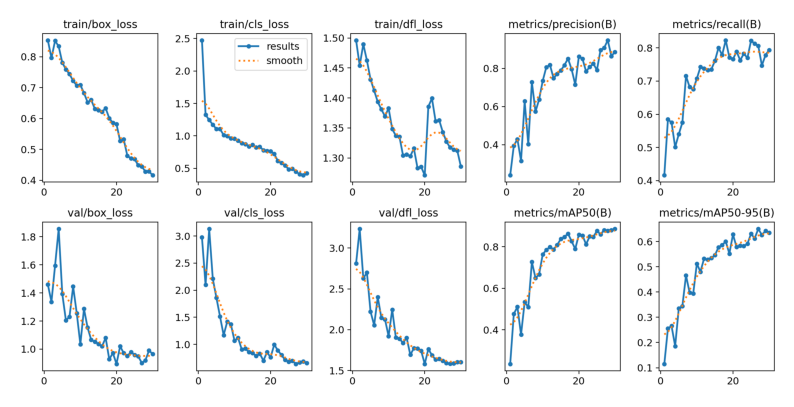

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/train2/results.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')


(np.float64(-0.5), np.float64(2249.5), np.float64(1499.5), np.float64(-0.5))

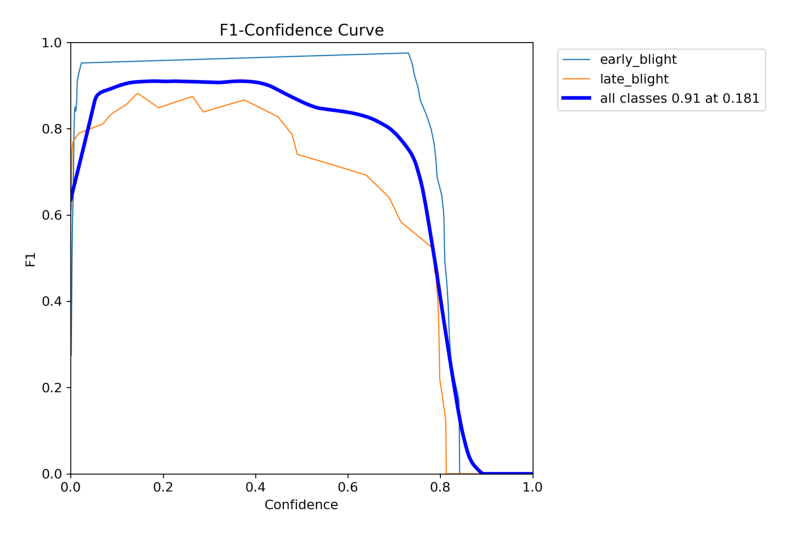

In [28]:
img = Image.open("/content/runs/detect/train-3/BoxF1_curve.png")
plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis('off')


In [29]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Test on a single image
image_path = '/content/test/images/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg'  # Replace with your image path

# Run inference
results = model(image_path)

# Display results
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    im.show()  # show image
    im.save('result.jpg')  # save image


image 1/1 /content/test/images/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg: 640x640 1 late_blight, 15.6ms
Speed: 4.8ms preprocess, 15.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)



image 1/1 /content/test/images/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg: 640x640 1 late_blight, 15.6ms
Speed: 2.1ms preprocess, 15.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


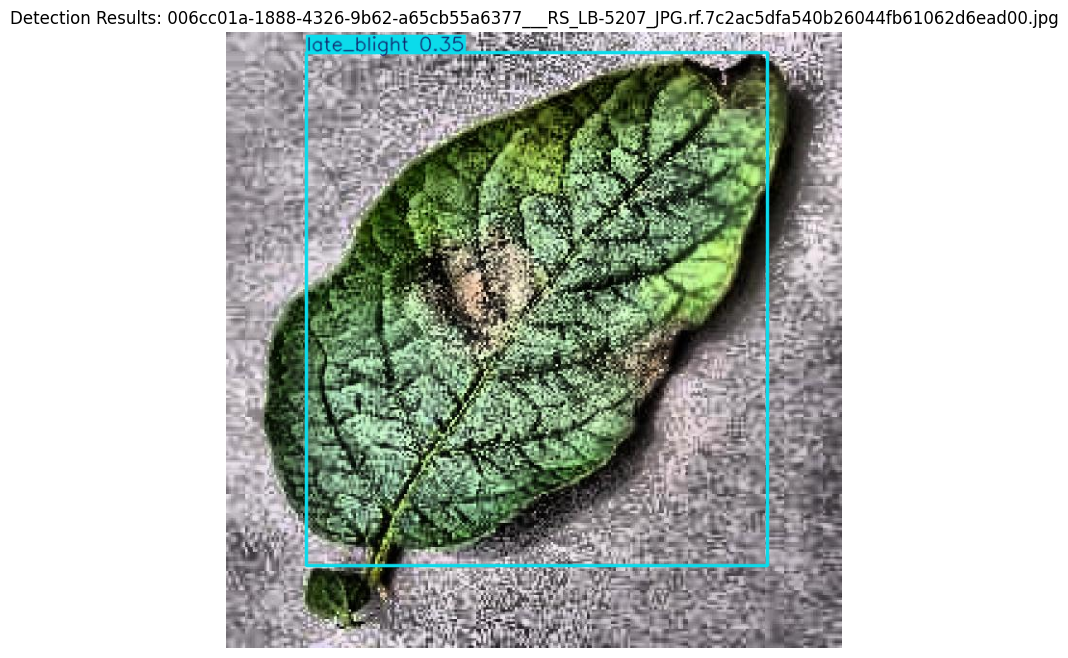

Result saved to: results/result_006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg


In [30]:
from ultralytics import YOLO
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import os
def test_single_image(image_path, output_dir='results'):
    """
    Test on a single image and return image with bounding boxes
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Run inference
    results = model(image_path)

    # Process results
    for i, r in enumerate(results):
        # Get image with bounding boxes
        im_array = r.plot()  # BGR numpy array with bounding boxes
        im_with_boxes = Image.fromarray(im_array[..., ::-1])  # Convert to RGB PIL Image

        # Save the result
        image_name = os.path.basename(image_path)
        output_path = os.path.join(output_dir, f'result_{image_name}')
        im_with_boxes.save(output_path)

        # Display the result
        plt.figure(figsize=(12, 8))
        plt.imshow(im_with_boxes)
        plt.axis('off')
        plt.title(f'Detection Results: {image_name}')
        plt.show()

        print(f"Result saved to: {output_path}")

        return im_with_boxes, output_path

# Usage
image_path = '/content/test/images/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB-5207_JPG.rf.7c2ac5dfa540b26044fb61062d6ead00.jpg'  # Replace with your image path
result_image, save_path = test_single_image(image_path)

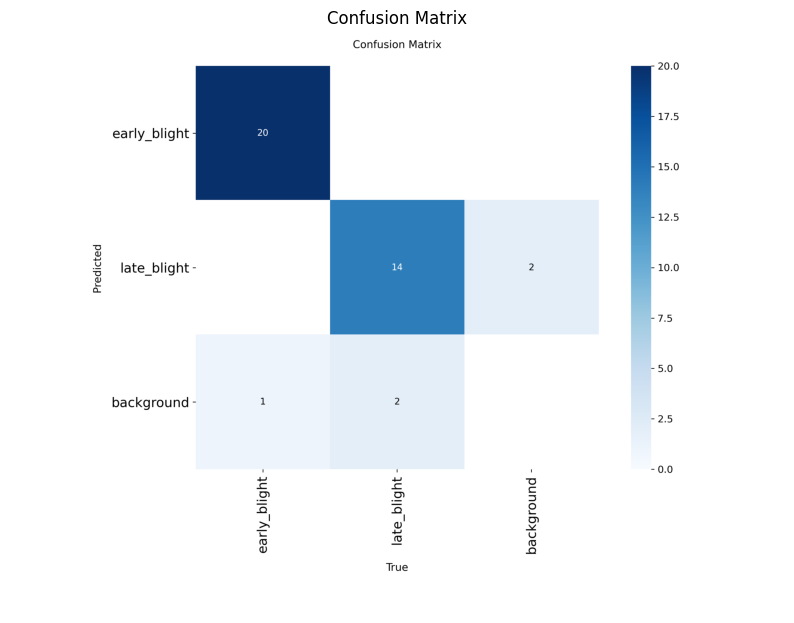

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

# Path to the confusion matrix image generated during training
confusion_matrix_path = "/content/runs/detect/train-3/confusion_matrix.png"

# Load and display the image
img = Image.open(confusion_matrix_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix')
plt.show()

In [32]:
import shutil

# Zip the runs folder
shutil.make_archive('runs_150', 'zip', 'runs')

'/content/runs_150.zip'

In [33]:
from google.colab import files
files.download('runs_150.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Download best model
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.export(format='tflite', imgsz=640)


Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (18.3 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<=1.19.1', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 2.02s
Prepared 11 packages in 6.55s
Installed 11 packages in 261ms
 + ai-edge-litert==2.1.0rc1
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.3
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.75
 + sng4onnx==1.0.4

requi

'/content/runs/detect/train/weights/best_saved_model/best_float32.tflite'

In [ ]:
from google.colab import files
files.download("/content/runs/detect/train/weights/best_saved_model/best_float32.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>